# Module 2: Epidemic Modeling Template

## Team Members:
Priya Shan, Owen Sines

## Module 2: Mystery Virus Analysis

## Project Goal:
This project seeks to monitor the behavior of an unknown virus, gather information about it based on creating models, and determine the most efficient methods of intervention.

## 1. Data and disease background
You can fill out this section throughout the module as you uncover more information about the mystery disease.

By the end of the module (when submitting), you should have some information about each of the following points:
* Prevalence & incidence in the UVA population
* Economic burden (you can generalize from respiratory viruses)
* Symptoms
* Biological mechanisms (anatomy, organ physiology, cell & molecular physiology - you can generalize from viral biology)

-The outbreak spreads quickly in the university population. From our SEIR model, active infections peak at around 3,000 students on day 80, which is about 16–17% of the population at once. During the fastest growth phase, there are roughly 120–130 new infections per day, showing how quickly the virus can move through dense indoor spaces like classrooms, residence halls, and dining areas. Since the virus spreads mainly through large droplets, close face-to-face interactions are the main way it’s transmitted.


-Even mild respiratory viruses can affect students’ daily lives and campus operations. Infected students may miss classes or exams, and staff may need to cover additional responsibilities. There’s also a cost in time and resources for student health services, isolation spaces, testing, and communication efforts. Altogether, these disruptions can affect both academic performance and the campus economy during an outbreak.


-Symptoms resemble those of common respiratory infections: fatigue, mild cough or sore throat, and low-grade fever. About 8% of cases report gastrointestinal issues, and some students get a rash. Symptoms usually last 5–9 days, and people may be contagious for about two days before showing symptoms, which makes the virus easier to spread.


-The virus appears to resemble a positive-sense RNA virus. After entering the respiratory tract, it infects airway cells and replicates, triggering an immune response that produces symptoms. Once cleared, individuals move into the recovered group and gain some immunity for a period of time. Transmission mainly occurs through close-contact droplets, which explains why outbreaks happen in crowded indoor areas.


## 2. Data Analysis
This section should be filled out sequentially as a full report of the work you've done over this module. You can copy and paste code from any main.py file here, and run it to produce plots. Once you gain more information throughout the module, you do not need to go back and "fix" earlier results. In other words, if your early predictions are found to be wrong when gaining new data, do not go back and rewrite them.

### 2a. Methods

*IN A SUMMARY, DESCRIBE THE METHODS YOU USED TO ANALYZE AND MODEL THE DATA.*


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #1</b> 

</div>



### Import Necessary Libraries 

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

### 2b. Plot the data & estimate initial growth rate (R0) from early data (through day 45)
This section should come from your python code after Data Release #1.

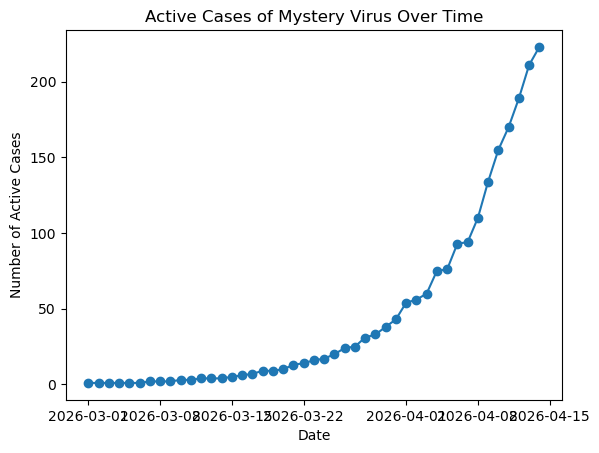

In [2]:
# Load the data
data = pd.read_csv(r'/Users/priya/Documents/Comp_Bio/GitHub/Module-2-Epidemics-SIR-Modeling/Data/mystery_virus_daily_active_counts_RELEASE#1.csv', parse_dates=['date'], header=0, index_col=None)
# Make a plot of the active cases over time
x_values = data['date']
y_values = data['active reported daily cases']
plt.plot(x_values, y_values, marker='o')
plt.title('Active Cases of Mystery Virus Over Time') 
plt.xlabel('Date') 
plt.ylabel('Number of Active Cases') 
plt.show() 

What do you notice about the initial infections? Seems to be following an exponential growth pattern 

How could we measure how quickly its spreading? Find the rate of growth of the curve 

What information about the virus would be helpful in determining the shape of the
outbreak curve? 

In [6]:
#Estimating the initial growth rate of the epidemic R0 from the early day 
def exponential_growth(t, r): #define exponential growth function to fit the data to 
    return np.exp(r * t)

x_values = data['day'] #set the x-values to the day from the initial outbreak instead of date 

popt, pcov = curve_fit(exponential_growth, x_values, y_values) #curve_fit uses non-linear least squares to fit a mathematical function to a set of data points
#function returns popt, which contains the optimal values for the parameters of the function (in this case, the growth rate r), and pcov, which is the covariance of the parameter estimates
r_estimated = popt[0] #extract the estimated growth rate from the optimal parameters
#predict intial growth rate given that the infectious period is 2 days 
R0_estimate = exponential_growth(2, r_estimated) #calculate the estimated number of cases after 1 day using the estimated growth rate
print(f"Estimated growth rate (r): {r_estimated}")
print(f"Estimated Initial Growth Rate: {R0_estimate}")



Estimated growth rate (r): 0.12144675524793189
Estimated Initial Growth Rate: 1.2749328499223294


What viruses have a similar R0? Use the viruses.html file to find a virus or 2 with a similar R0 and give a 1-2 sentence background of the diseases.

-Viruses with a similar (R_0) to our estimate of about 1.27 include seasonal influenza and the 2009 H1N1 (swine flu) virus. Seasonal influenza typically has an (R_0) around 1.2–2, meaning each infected person spreads the virus to about one or two others, mainly through respiratory droplets from coughing or sneezing. The 2009 H1N1 influenza strain had an estimated (R_0) of about 1.4 and spread globally in 2009, causing flu-like symptoms such as fever, cough, and fatigue.

How accurate do you think your R0 estimate is?

-The (R_0) estimate is likely somewhat accurate but not exact because it depends on assumptions in the model and the quality of the data, so the true value could be slightly higher or lower.


Plotting the estimated exponential curve over the scatterplot

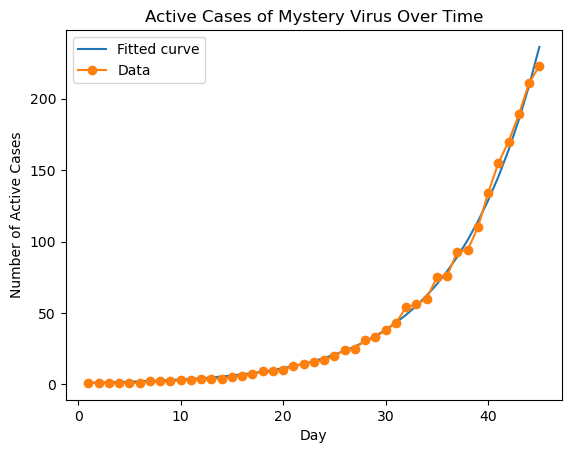

In [10]:
plt.plot(x_values, exponential_growth(x_values, popt), label='Fitted curve')
plt.plot(x_values, y_values, marker='o', label='Data')
plt.title('Active Cases of Mystery Virus Over Time') 
plt.xlabel('Day') 
plt.ylabel('Number of Active Cases') 
plt.legend()
plt.show()


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #2</b> 

</div>



### 2c. Use Euler's method to solve the SEIR model.
This section should come from your python code after Data Release #2.

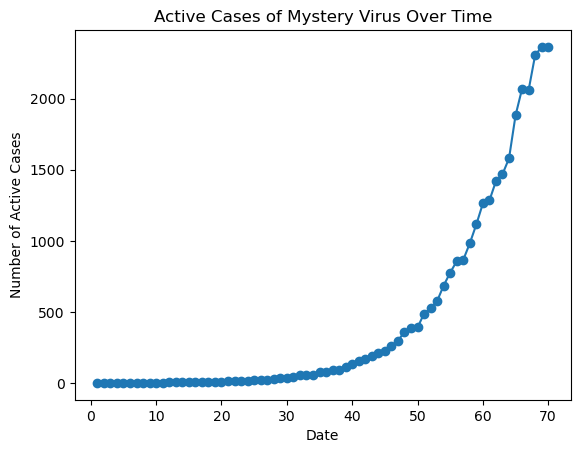

In [11]:
#Load data from release #2
data = pd.read_csv(r'/Users/priya/Documents/Comp_Bio/GitHub/Module-2-Epidemics-SIR-Modeling/Data/mystery_virus_daily_active_counts_RELEASE#2.csv', parse_dates=['date'], header=0, index_col=None)
#Make a plot of new active cases over time 
x_values = data['day']
y_values = data['active reported daily cases']
plt.plot(x_values, y_values, marker='o')
plt.title('Active Cases of Mystery Virus Over Time') 
plt.xlabel('Date') 
plt.ylabel('Number of Active Cases') 
plt.show() 

In [17]:
'''
INPUTS: beta, sigma, gamma, S0, E0, I0, R0, timepoints, N
Initialize S, E, I, and R as empty arrays or lists
Set first item in each list equal to initial values S0, E0, I0, R0
 '''
def seir_euler(beta, sigma, gamma, S0, E0, I0, R0, timepoints, N):
    dt = timepoints[1] - timepoints[0]
    S = np.zeros(len(timepoints))
    E = np.zeros(len(timepoints))
    I = np.zeros(len(timepoints))
    R = np.zeros(len(timepoints))
    #add initial value to first index of each list
    S[0] = S0
    E[0] = E0
    I[0] = I0
    R[0] = R0
    #for each timepoint in timepoints: 
    for t in range(len(timepoints)-1):
        #Calculate the four derivatives at timepoint
        dS = - (beta * S[t] * I[t]) / N
        dE = (beta * S[t] * I[t]) / N - (sigma * E[t])
        dI = (sigma * E[t]) - (gamma * I[t])
        dR = (gamma * I[t])
      #  Calculate S, E, I, and R at timepoint + 1 using Euler’s method
        S[t+1] = S[t] + dS * dt
        E[t+1] = E[t] + dE * dt
        I[t+1] = I[t] + dI * dt
        R[t+1] = R[t] + dR * dt  
    return S, E, I, R

N = 17900 #population size at UVA 
S0 = N-40
E0 = 40 #assumption for now, will be accounted for by grid search optimization 
I0 = 1
R0 = 0

### 2d. Fit the SEIR model to the data by changing beta, gamma, and sigma.
This section should come from your python code after Data Release #2.

In [18]:
#Grid search optimization 
#Initialize a range for beta, sigma, and gamma
beta_range = np.linspace(0.1, 1.5, 10) #beta = R0 / D = 1.274 / 2 = 0.637, so we want to search around that value
sigma_range = np.linspace(0.055, 0.09, 5) #based on incubation period of 12-18 days, so sigma = 1 / incubation period = 1/12 to 1/18
gamma_range = np.linspace(0.1, 0.7, 10) #recovery rate = 1/2 = 0.5, so we want to search around that value 
#Initialize an empty array of SSE
best_sse = float('inf')
best_params = (0,0,0)
#search through each range of values for beta, sigma, and gamma
for b in beta_range:
    for g in gamma_range:
        for s in sigma_range:
#Use the Euler method function to calculate S, E, I, and R given those parameters
            S, E, I, R = seir_euler(b, s, g, S0, E0, I0, R0, x_values, N)
#Calculate the SSE given the model results and the data and append this to the SSE array	
            sse = np.sum((I - y_values)**2)
            if sse < best_sse:
                best_sse = sse
                best_params = (b, s, g)
#Determine parameters corresponding to lowest SSE
#Return best_beta, best_sigma, and best_gamma and corresponding SSE
best_beta, best_sigma, best_gamma = best_params
print(f"Best beta: {best_beta}, Best sigma: {best_sigma}, Best gamma: {best_gamma}, SSE: {best_sse}")

Best beta: 0.5666666666666667, Best sigma: 0.055, Best gamma: 0.1, SSE: 1001817.4889658531


### 2e. Plot the model-predicted infections over time compared to the data.
This section should come from your python code after Data Release #2.

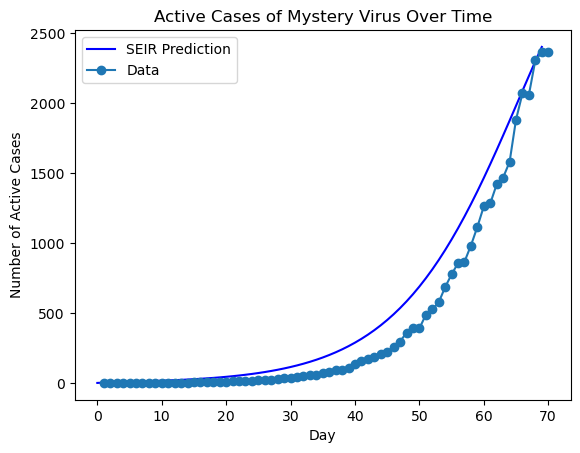

In [28]:
timepoints_70 = np.arange(0, 70, 1)
S, E, I, R = seir_euler(best_beta, best_sigma, best_gamma, S0, E0, I0, R0, timepoints_70, N)
plt.plot(timepoints_70, I, 'b-', label='SEIR Prediction')
plt.plot(x_values, y_values, marker='o', label='Data')
plt.title('Active Cases of Mystery Virus Over Time') 
plt.xlabel('Day') 
plt.ylabel('Number of Active Cases') 
plt.legend() 
plt.show() 

### 2e. Predict the day and amount of active cases at the peak of the epidemic spread.
This section should come from your python code after Data Release #2.


In [29]:
future_timepoints = np.arange(0, 150, 1) #extrapolate past the given data points to predict the future 
S_f, E_f, I_f, R_f = seir_euler(best_beta, best_sigma, best_gamma, S0, E0, I0, R0, future_timepoints, N)
peak_idx = np.argmax(I_f)
peak_day = future_timepoints[peak_idx]
peak_cases = I_f[peak_idx]
print(f"Predicted peak day: {peak_day}")
print(f"Predicted peak cases: {peak_cases}")

Predicted peak day: 83
Predicted peak cases: 3191.4875116963453



<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #3</b> 

</div>



### 2f. Plot the full dataset (Data Release #3) against your model.
This section should come from your python code after Data Release #3.


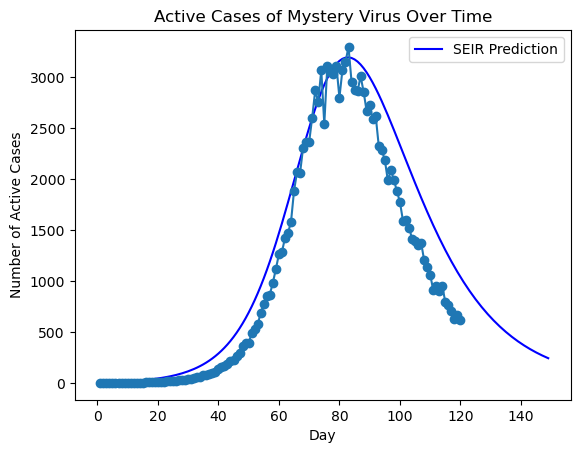

In [30]:
data = pd.read_csv(r'/Users/priya/Documents/Comp_Bio/GitHub/Module-2-Epidemics-SIR-Modeling/Data/mystery_virus_daily_active_counts_RELEASE#3.csv', parse_dates=['date'], header=0, index_col=None)
x_values = data['day']
y_values = data['active reported daily cases']
plt.plot(future_timepoints, I_f, 'b-', label='SEIR Prediction')
plt.plot(x_values, y_values, marker='o')
plt.title('Active Cases of Mystery Virus Over Time') 
plt.xlabel('Day') 
plt.ylabel('Number of Active Cases') 
plt.legend()
plt.show()

### Percent Error with SEIR Model 
Percent Error for Peak Number of Cases: 3191.49 - 3294 / 3191.49 = 3.211%

Percent Error for Peak Day: 83-83/83 = 0%

discuss why your model has the error it does (i.e. model limitations) and whether the error level is too high to trust your predictions


### 2g. Intervention strategies for new outbreak at VT (70 days of infection)
This section should come from your python code after Data Release #3.



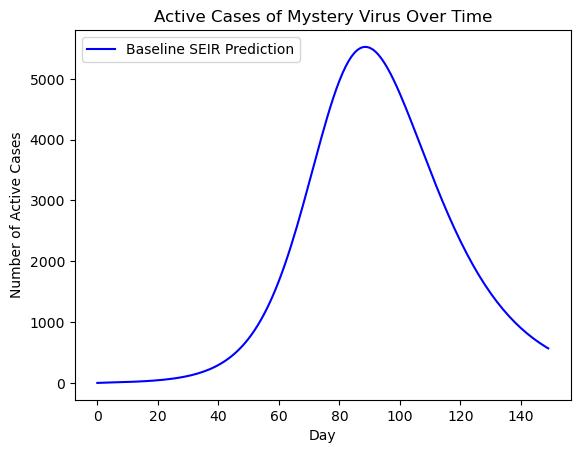

In [36]:
#Baseline Prediction for new outbreak at VT 
N_VT = 31000 #population size at VT
S0_VT = N_VT-40
E0_VT = 40 #assumption for now, will be accounted for by grid search optimization 
I0_VT = 1
R0_VT = 0
S_baseline, E_baseline, I_baseline, R_baseline = seir_euler(best_beta, best_sigma, best_gamma, S0_VT, E0_VT, I0_VT, R0_VT, future_timepoints, N_VT)
plt.plot(future_timepoints, I_baseline, 'b-', label='Baseline SEIR Prediction')
plt.title('Active Cases of Mystery Virus Over Time') 
plt.xlabel('Day') 
plt.ylabel('Number of Active Cases') 
plt.legend()
plt.show()

### Intervention Method 1: 

## Verify and validate your analysis: 

*(Describe how you checked to see that your analysis gave you an answer that you believe (verify). Describe how your determined if your analysis gave you an answer that is supported by other evidence (e.g., a published paper).*


To verify our analysis, we checked whether the model behaved the way an outbreak is expected to behave. In the simulation, infections increased quickly at the start when most people were still susceptible. Over time, the number of susceptible individuals decreased, which slowed the spread and eventually caused infections to peak and decline. This pattern matches the typical epidemic curve predicted by SIR models.

We also checked that the total population stayed constant throughout the simulation. Individuals only moved between the susceptible, infected, and recovered groups, and no people were added or removed from the system. Seeing these expected patterns gave us confidence that the model and code were working correctly.
https://jamanetwork.com/journals/jama/fullarticle/2766672

To validate our results, we compared the pattern produced by our model to what has been observed in real epidemic studies. Classic epidemic theory shows that outbreaks usually start with rapid growth in infections, reach a peak, and then decline as fewer people remain susceptible.

The infection curve produced by our model followed this same general pattern. This suggests that the model captures the basic dynamics of how diseases spread through a population. While the model simplifies real conditions and assumes everyone mixes evenly, the overall trend is consistent with established epidemic theory.
https://royalsocietypublishing.org/rspa/article/115/772/700/2165/A-contribution-to-the-mathematical-theory-of 


## Conclusions and Ethical Implications: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## Limitations and Future Work: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*